In [1]:
import pyettj as ettj
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

pyettj 0.4.0


In [2]:
# ── 1. Coletar dados históricos ──────────────────────────────────────────────
df = ettj.get_ettj_historico(
    "01/03/2026", "18/04/2026",   # ajuste o intervalo desejado
    curva="PRE",
)

datas = sorted(df["refdate"].unique())

# ── 2. Pré-calcular limites fixos para o eixo Y ───────────────────────────────
taxa_min = df["taxa"].min() * 100 * 0.995
taxa_max = df["taxa"].max() * 100 * 1.005

[pyettj] Cache: 02/03/2026 (salvo há 8min)
[pyettj] Cache: 03/03/2026 (salvo há 1min)
[pyettj] Cache: 04/03/2026 (salvo há 1min)
[pyettj] Cache: 05/03/2026 (salvo há 4min)
[pyettj] Cache: 06/03/2026 (salvo há 4min)
[pyettj] Cache: 09/03/2026 (salvo há 4min)
[pyettj] Cache: 10/03/2026 (salvo há 4min)
[pyettj] Cache: 11/03/2026 (salvo há 4min)
[pyettj] Cache: 12/03/2026 (salvo há 4min)
[pyettj] Cache: 13/03/2026 (salvo há 4min)
[pyettj] Cache: 16/03/2026 (salvo há 4min)
[pyettj] Cache: 17/03/2026 (salvo há 4min)
[pyettj] Cache: 18/03/2026 (salvo há 4min)
[pyettj] Cache: 19/03/2026 (salvo há 4min)
[pyettj] Cache: 20/03/2026 (salvo há 4min)
[pyettj] Cache: 23/03/2026 (salvo há 4min)
[pyettj] Cache: 24/03/2026 (salvo há 4min)
[pyettj] Cache: 25/03/2026 (salvo há 4min)
[pyettj] Cache: 26/03/2026 (salvo há 4min)
[pyettj] Cache: 27/03/2026 (salvo há 4min)
[pyettj] Cache: 30/03/2026 (salvo há 4min)
[pyettj] Cache: 31/03/2026 (salvo há 4min)
[pyettj] Cache: 01/04/2026 (salvo há 4min)
[pyettj] Ca

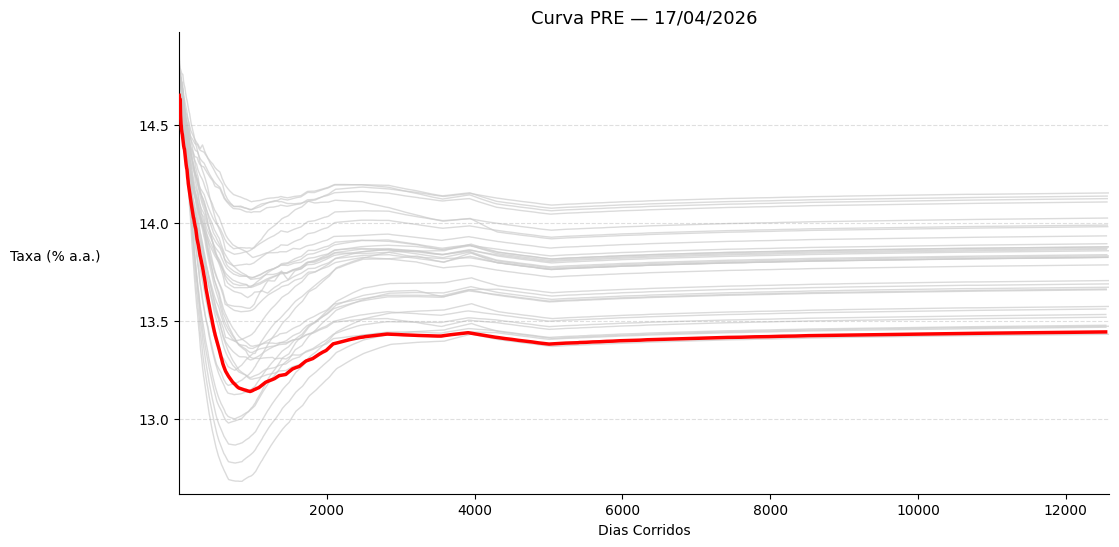

In [4]:
x_min = df["dias_corridos"].min()
x_max = df["dias_corridos"].max()

# ── 3. Montar a figura ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.set_xlim(x_min, x_max)
ax.set_ylim(taxa_min, taxa_max)
ax.set_xlabel("Dias Corridos")
ax.set_ylabel("Taxa (% a.a.)", rotation=0, labelpad=60)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

titulo = ax.set_title("", fontsize=13)

# Uma linha cinza por data histórica (todas criadas vazias)
linhas_historico = []
for _ in datas:
    l, = ax.plot([], [], color="#cccccc", lw=1, alpha=0.7, zorder=1)
    linhas_historico.append(l)

# Linha em destaque (atual) — sempre por cima
linha_atual, = ax.plot([], [], color="red", lw=2.5, zorder=3)

# ── 4. Funções de animação ────────────────────────────────────────────────────
def init():
    for l in linhas_historico:
        l.set_data([], [])
    linha_atual.set_data([], [])
    titulo.set_text("")
    return linhas_historico + [linha_atual, titulo]

def update(frame):
    data_ref = datas[frame]

    # Preenche todas as curvas até o frame atual em cinza
    for i, l in enumerate(linhas_historico):
        if i < frame:          # curvas passadas → cinza
            sub = df[df["refdate"] == datas[i]].sort_values("dias_corridos")
            l.set_data(sub["dias_corridos"], sub["taxa"] * 100)
        else:
            l.set_data([], []) # curvas futuras → invisíveis

    # Curva atual em vermelho
    sub_atual = df[df["refdate"] == data_ref].sort_values("dias_corridos")
    linha_atual.set_data(sub_atual["dias_corridos"], sub_atual["taxa"] * 100)

    titulo.set_text(f"Curva PRE — {data_ref.strftime('%d/%m/%Y')}")
    return linhas_historico + [linha_atual, titulo]

# ── 5. Gerar e salvar GIF ─────────────────────────────────────────────────────
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(datas),
    init_func=init,
    interval=200,
    blit=True,
)

HTML(ani.to_jshtml())

In [5]:
ani.save(
    "curva_pre.gif",
    writer=animation.PillowWriter(fps=5),
    dpi=120,
)

plt.close(fig)
print("GIF salvo como curva_pre.gif")

GIF salvo em curva_pre.gif
